# FloodSense Nigeria -- FIXED ML Pipeline (Phase 0-10)


## Phase 0: Environment Setup


In [ ]:
!pip install xgboost shap matplotlib seaborn scipy scikit-learn pandas numpy joblib -q
print('Packages ready')


Packages ready


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.signal import fftconvolve, correlate
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)
import xgboost as xgb
import shap, joblib, json, calendar
from pathlib import Path
from collections import deque

np.random.seed(42)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

Path('models').mkdir(exist_ok=True)

FLOOD_THRESHOLD_CM = 400.0   # 4 metres
DECISION_THRESHOLD  = 0.40   # 40% -- biased for recall

print(f'Flood threshold = {FLOOD_THRESHOLD_CM} cm | Decision threshold = {DECISION_THRESHOLD}')


Flood threshold = 400.0 cm | Decision threshold = 0.4


## Phase 1: Data Loading and Synthetic Dataset Generation
### Step 1a -- Upload CHIRPS CSV


In [4]:
from google.colab import files
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print(f'Uploaded: {csv_name}')


Saving nga-rainfall-subnat-5ytd.csv to nga-rainfall-subnat-5ytd.csv
Uploaded: nga-rainfall-subnat-5ytd.csv


In [5]:
df_raw = pd.read_csv(csv_name)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Shape: {df_raw.shape}')
print(f'Date range: {df_raw["date"].min()} to {df_raw["date"].max()}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)


Shape: (122553, 15)
Date range: 2022-01-01 00:00:00 to 2026-03-21 00:00:00
Columns: ['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version']


,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,2022-01-01,1,2211,NG002,1133.0,0.058252,0.051280,0.178288,0.112415,81.817290,62.170403,100.138030,101.288475,129.24933,final
1,2022-01-11,1,2211,NG002,1133.0,0.060900,0.068814,0.211827,0.158223,39.045900,28.427890,99.843864,101.039185,131.76392,final
2,2022-01-21,1,2211,NG002,1133.0,0.115622,0.140688,0.234775,0.260783,4.736981,3.426890,99.512390,99.505630,115.54654,final


### Step 1b -- Select Bayelsa (NG006)
Highest mean wet-season rainfall (~114 mm/10-day), Niger Delta, most flood-prone state.
adm_level=1 = state aggregate. Filter to final/prelim observations only.


In [6]:
mask = (
    (df_raw['PCODE'] == 'NG006') &
    (df_raw['adm_level'] == 1) &
    (df_raw['version'].isin(['final', 'prelim']))
)
df_state = df_raw[mask].sort_values('date').reset_index(drop=True)
print(f'Bayelsa dekadal rows: {len(df_state)}')
print(f'Date range: {df_state["date"].min()} to {df_state["date"].max()}')
print('rfh (10-day mm) stats:')
print(df_state['rfh'].describe().round(2))
df_state[['date','rfh','r1h','r3h']].head()


Bayelsa dekadal rows: 152
Date range: 2022-01-01 00:00:00 to 2026-03-11 00:00:00
rfh (10-day mm) stats:
count    152.00
mean      74.03
std       58.47
min        1.95
25%       24.79
50%       64.83
75%      120.91
max      280.63
Name: rfh, dtype: float64


,date,rfh,r1h,r3h
0,2022-01-01,15.562112,31.009315,648.68320
1,2022-01-11,24.860249,49.770187,547.56213
2,2022-01-21,4.611801,45.034160,385.91614
3,2022-02-01,7.962733,37.434784,290.02487
4,2022-02-11,16.304348,28.878881,203.94722


### Step 1c -- Disaggregate Dekadal to Hourly Rainfall
Two physical priors:
1. Dirichlet allocation: lumpy rainfall (2-3 heavy days per 10-day window)
2. Tropical diurnal cycle: Nigeria convective rain peaks 14:00-19:00


In [7]:
def diurnal_weights():
    h = np.arange(24)
    w = (0.3 * np.exp(-0.5 * ((h - 10) / 2.0)**2) +
         0.7 * np.exp(-0.5 * ((h - 16) / 2.5)**2))
    w += 0.02
    return w / w.sum()

DIURNAL = diurnal_weights()

def disaggregate_dekad(start, total_mm, n_days=10, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    n_h = n_days * 24
    ts  = pd.date_range(start, periods=n_h, freq='h')
    if total_mm <= 0:
        return pd.Series(np.zeros(n_h), index=ts)
    day_props  = rng.dirichlet(np.ones(n_days) * 0.8)
    day_totals = day_props * total_mm
    hourly = np.zeros(n_h)
    for d in range(n_days):
        dr = day_totals[d]
        if dr < 0.5:
            hourly[d*24:(d+1)*24] = dr / 24
        else:
            hourly[d*24:(d+1)*24] = rng.dirichlet(DIURNAL * 10) * dr
    return pd.Series(np.maximum(hourly, 0), index=ts)

rng = np.random.default_rng(42)
parts = []
for _, row in df_state.iterrows():
    nd = (calendar.monthrange(row['date'].year, row['date'].month)[1] - 20
          if row['date'].day == 21 else 10)
    parts.append(disaggregate_dekad(row['date'], row['rfh'], n_days=nd, rng=rng))

hourly_rain = pd.concat(parts).sort_index()
t0 = pd.Timestamp('2023-05-01')
hourly_rain = hourly_rain.reindex(pd.date_range(t0, periods=7000, freq='h'), fill_value=0.0)
rain_arr = hourly_rain.values

print(f'Hourly series: {len(hourly_rain):,} rows')
print(f'Period: {hourly_rain.index[0]} to {hourly_rain.index[-1]}')
print(f'Total: {rain_arr.sum():.1f} mm  |  Max 1h: {rain_arr.max():.2f} mm')


Hourly series: 7,000 rows
Period: 2023-05-01 00:00:00 to 2024-02-16 15:00:00
Total: 2759.9 mm  |  Max 1h: 24.81 mm


### Step 1d -- Generate BASELINE Water Level (hard-capped at 325cm)
The baseline from the hydrograph NEVER crosses 400cm.
Flood events are injected separately in Step 1e with controlled durations.
This gap (325cm baseline vs 400cm threshold) is essential for label divergence.


In [8]:
hydrograph = np.zeros(24)
for i in range(24):
    hydrograph[i] = i / 3 if i <= 3 else max(0.0, 1.0 - (i - 3) / 21)
hydrograph /= hydrograph.sum()

n = len(rain_arr)
sm = np.zeros(n)
for i in range(1, n):
    sm[i] = min(1.0, sm[i-1] * 0.97 + rain_arr[i] * 0.006)
runoff_frac = 0.15 + 0.70 * sm
eff_rain    = rain_arr * runoff_frac

response = fftconvolve(eff_rain, hydrograph)[:n]

p999  = np.percentile(response, 99.9)
scale = 320.0 / (p999 + 1e-9)
wl_base = 80.0 + response * scale
wl_base += np.random.normal(0, 1.5, n)
wl_base  = np.clip(wl_base, 0.0, 325.0)   # hard cap -- NEVER reaches threshold

print('Baseline water level (before event injection):')
print(f'  Min:  {wl_base.min():.1f} cm')
print(f'  Mean: {wl_base.mean():.1f} cm')
print(f'  Max:  {wl_base.max():.1f} cm')
print(f'  Hours >= 400cm: {(wl_base >= 400).sum()}  (must be ZERO)')


Baseline water level (before event injection):
  Min:  75.8 cm
  Mean: 97.7 cm
  Max:  325.0 cm
  Hours >= 400cm: 0  (must be ZERO)


### Step 1e -- Inject Flood Events: The Key Fix

**Why identical matrices happened:** Sustained 15-20h floods make 1h/3h/6h labels
fire on almost the same rows. Three models learn the same decision boundary.

**The fix -- three event types with controlled duration above threshold:**

| Type | Duration above 400cm | Effect on labels |
|---|---|---|
| Flash | 1-2 hours | 6h fires 6h before; 1h fires only at the peak |
| Medium | 4-8 hours | 6h/3h/1h fire at clearly different times |
| Sustained | 10-18 hours | All fire, but at different lead distances |
| Near-miss | 0 hours (peak 370-399cm) | All labels stay 0 -- trains model to distinguish |

Each event has 3 phases: 3h rise, N hours sustained, 5h fall.
Events are separated by MIN_GAP=30h to prevent label windows from overlapping.


In [9]:
def inject_flood_events(wl_baseline, n, rng, flood_threshold=400.0):
    wl       = wl_baseline.copy()
    occupied = np.zeros(n, dtype=bool)
    log      = []

    RISE_H  = 3
    FALL_H  = 5
    MIN_GAP = 30

    def try_inject(start, peak_cm, dur_above, is_nm=False):
        total = RISE_H + dur_above + FALL_H
        if start + total >= n:
            return False
        gap   = MIN_GAP // 2 if is_nm else MIN_GAP
        buf_s = max(0, start - gap)
        buf_e = min(n, start + total + gap)
        if occupied[buf_s:buf_e].any():
            return False
        for h in range(total):
            idx = start + h
            bl  = wl_baseline[idx]
            if h < RISE_H:
                lvl = bl + (h / RISE_H) * (peak_cm - bl)
            elif h < RISE_H + dur_above:
                lvl = peak_cm + rng.uniform(-3, 3)
            else:
                frac = (h - RISE_H - dur_above) / FALL_H
                lvl  = peak_cm - frac * (peak_cm - bl)
            if is_nm:
                lvl = min(lvl, flood_threshold - 0.5)
            wl[idx] = max(wl[idx], lvl)
        occupied[buf_s:buf_e] = True
        return True

    def inject_batch(label, n_target, dur_lo, dur_hi, peak_lo, peak_hi, is_nm=False):
        done = 0
        for _ in range(n_target * 6):
            if done >= n_target:
                break
            start   = int(rng.integers(RISE_H + 10, n - 100))
            peak_cm = float(rng.uniform(peak_lo, peak_hi))
            dur     = int(rng.integers(dur_lo, dur_hi + 1))
            if try_inject(start, peak_cm, dur, is_nm=is_nm):
                log.append({'type': label, 'start': start,
                            'dur': dur, 'peak': round(peak_cm, 1)})
                done += 1
        return done

    nf  = inject_batch('flash',     16, 1,  2,  405, 445)
    nm_ = inject_batch('medium',    12, 4,  8,  405, 465)
    ns  = inject_batch('sustained',  6, 10, 18, 410, 490)
    nnm = inject_batch('near_miss', 22, 2,  8,  370, 399, is_nm=True)

    print('Events injected:')
    print(f'  Flash     (1-2h above threshold):   {nf}')
    print(f'  Medium    (4-8h above threshold):   {nm_}')
    print(f'  Sustained (10-18h):                 {ns}')
    print(f'  Near-miss (370-399cm, no crossing): {nnm}')
    return wl, log


wl, event_log = inject_flood_events(wl_base, n, rng)
event_df = pd.DataFrame(event_log)

print(f'\nFinal water level stats:')
print(f'  Min:  {wl.min():.1f} cm')
print(f'  Mean: {wl.mean():.1f} cm')
print(f'  Max:  {wl.max():.1f} cm')
print(f'  Hours >= 400cm (flood events): {(wl >= 400).sum()}')
print(f'  Hours 370-399cm (near-miss):   {((wl >= 370) & (wl < 400)).sum()}')


Events injected:
  Flash     (1-2h above threshold):   16
  Medium    (4-8h above threshold):   12
  Sustained (10-18h):                 6
  Near-miss (370-399cm, no crossing): 22

Final water level stats:
  Min:  76.0 cm
  Mean: 120.5 cm
  Max:  473.7 cm
  Hours >= 400cm (flood events): 208
  Hours 370-399cm (near-miss):   147


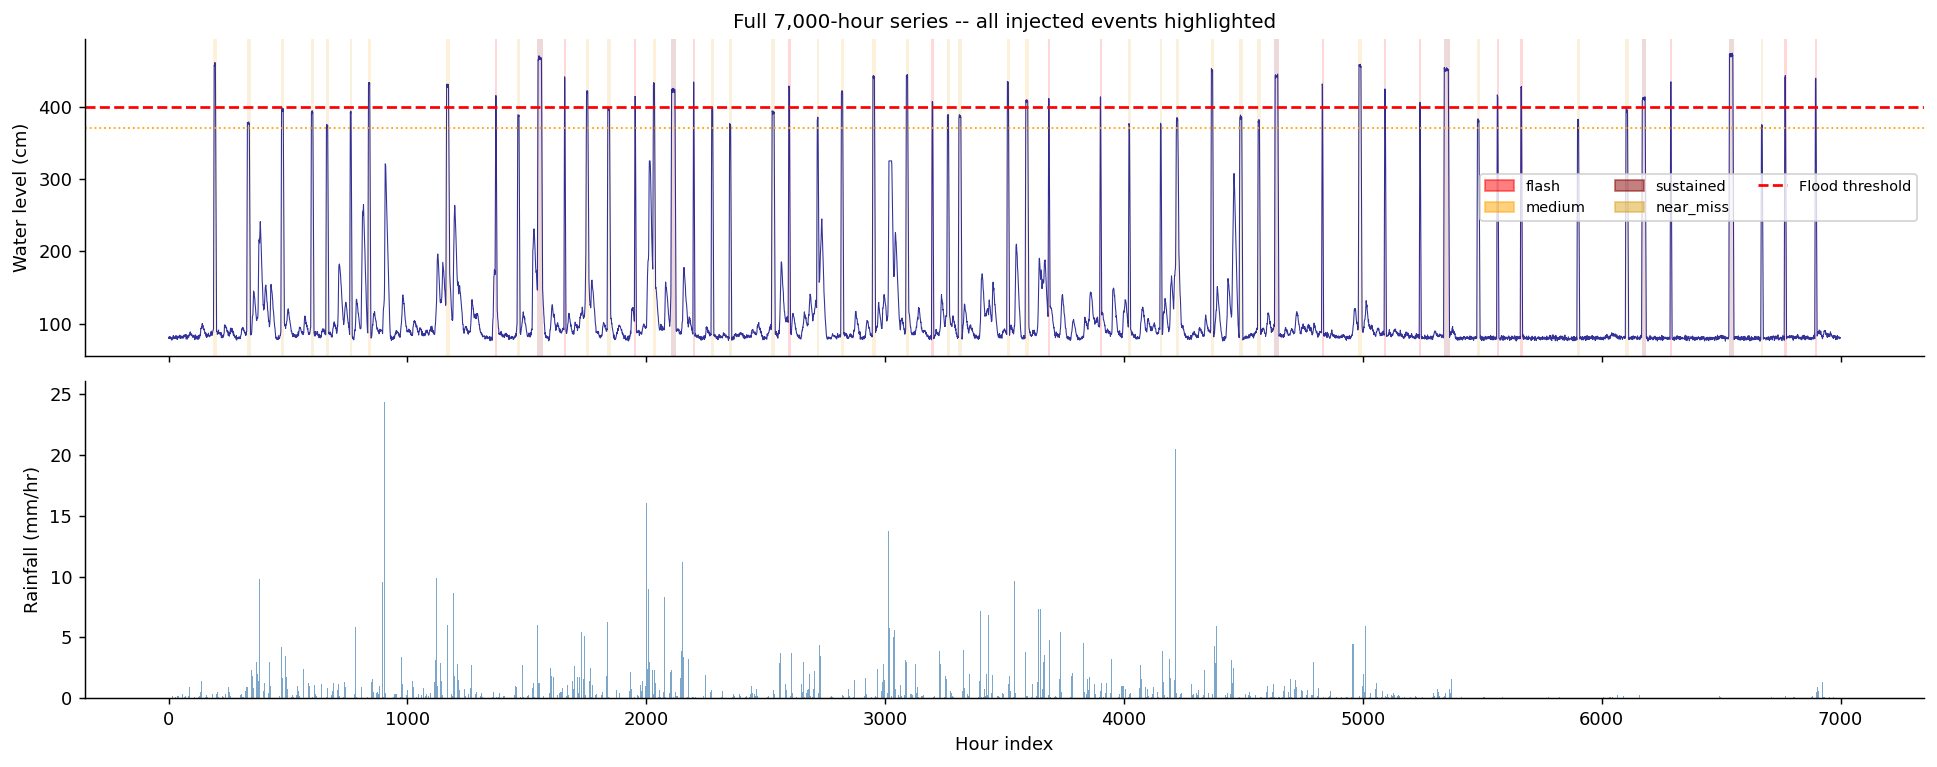

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
x = np.arange(n)

axes[0].plot(x, wl, color='navy', lw=0.6, alpha=0.8)
axes[0].axhline(FLOOD_THRESHOLD_CM, color='red', ls='--', lw=1.5, label='Flood threshold (400cm)')
axes[0].axhline(370, color='orange', ls=':', lw=1, label='Near-miss zone (370-400cm)')

colours_ev = {'flash': 'red', 'medium': 'orange',
               'sustained': 'darkred', 'near_miss': 'goldenrod'}
for _, ev in event_df.iterrows():
    axes[0].axvspan(ev['start'], ev['start'] + ev['dur'] + 8,
                    alpha=0.15, color=colours_ev[ev['type']], lw=0)

from matplotlib.patches import Patch
legend_els = [Patch(color=v, alpha=0.5, label=k) for k, v in colours_ev.items()]
legend_els += [plt.Line2D([0],[0], color='red', ls='--', label='Flood threshold')]
axes[0].legend(handles=legend_els, fontsize=8, ncol=3)
axes[0].set_ylabel('Water level (cm)')
axes[0].set_title('Full 7,000-hour series -- all injected events highlighted', fontsize=11)

axes[1].bar(x, rain_arr, color='steelblue', alpha=0.7, width=1)
axes[1].set_ylabel('Rainfall (mm/hr)')
axes[1].set_xlabel('Hour index')

plt.tight_layout()
plt.savefig('event_timeline.png', dpi=130, bbox_inches='tight')
plt.show()


### Step 1f -- Assemble All Features


In [11]:
timestamps = pd.date_range('2023-05-01', periods=7000, freq='h')

df = pd.DataFrame({
    'timestamp':      timestamps,
    'rainfall_mm':    np.round(rain_arr, 3),
    'water_level_cm': np.round(wl, 1),
})

# Requested features
df['rainfall_1h']  = df['rainfall_mm'].rolling(1,  min_periods=1).sum()
df['rainfall_3h']  = df['rainfall_mm'].rolling(3,  min_periods=1).sum()
df['rainfall_6h']  = df['rainfall_mm'].rolling(6,  min_periods=1).sum()
df['rainfall_24h'] = df['rainfall_mm'].rolling(24, min_periods=1).sum()
df['level_rate_of_change'] = df['water_level_cm'].diff().fillna(0.0)
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_year'] = df['timestamp'].dt.dayofyear
df['antecedent_soil_moisture'] = df['rainfall_mm'].rolling(72, min_periods=1).sum()

# Extended features
df['level_2h_ago']      = df['water_level_cm'].shift(2).bfill()
df['level_6h_ago']      = df['water_level_cm'].shift(6).bfill()
df['level_accel']       = df['level_rate_of_change'].diff().fillna(0.0)
df['rain_intensity_6h'] = df['rainfall_mm'].rolling(6, min_periods=1).max()
df['hour_sin']          = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']          = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['doy_sin']           = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']           = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['rain_x_rising']     = df['rainfall_3h'] * df['level_rate_of_change'].clip(lower=0)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
missing = df.isnull().sum()
print(f'Missing: {missing[missing>0].to_dict() or "None"}')


Dataset shape: (7000, 20)
Columns: ['timestamp', 'rainfall_mm', 'water_level_cm', 'rainfall_1h', 'rainfall_3h', 'rainfall_6h', 'rainfall_24h', 'level_rate_of_change', 'hour_of_day', 'day_of_year', 'antecedent_soil_moisture', 'level_2h_ago', 'level_6h_ago', 'level_accel', 'rain_intensity_6h', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'rain_x_rising']
Missing: None


### Step 1g -- Generate Multi-Horizon Flood Labels


In [12]:
lvl = df['water_level_cm'].values
Nrows = len(lvl)

for col, h in [('flood_alert_1h', 1), ('flood_alert_3h', 3), ('flood_alert_6h', 6)]:
    labels = np.zeros(Nrows, dtype=int)
    for i in range(Nrows - h):
        if np.any(lvl[i+1 : i+1+h] >= FLOOD_THRESHOLD_CM):
            labels[i] = 1
    df[col] = labels

print('Label distribution:')
for c in ['flood_alert_1h', 'flood_alert_3h', 'flood_alert_6h']:
    print(f'  {c}: {df[c].mean()*100:.2f}% positive ({df[c].sum()} hours)')


Label distribution:
  flood_alert_1h: 2.97% positive (208 hours)
  flood_alert_3h: 3.94% positive (276 hours)
  flood_alert_6h: 5.40% positive (378 hours)


### Step 1h -- VALIDATION: Verify Label Divergence

This cell proves the fix worked. Three rows should be clearly non-zero and different.
In the broken version, `only_6h` and `only_3h_and_6h` were near zero.


In [13]:
a1 = df['flood_alert_1h'].values
a3 = df['flood_alert_3h'].values
a6 = df['flood_alert_6h'].values

only_6h    = ((a6==1) & (a3==0) & (a1==0)).sum()
six_and_3h = ((a6==1) & (a3==1) & (a1==0)).sum()
all_three  = ((a6==1) & (a3==1) & (a1==1)).sum()
total_1h   = a1.sum()
total_3h   = a3.sum()
total_6h   = a6.sum()

print('Label overlap analysis:')
print(f'  flood_alert_6h positives: {total_6h}  ({total_6h/Nrows*100:.2f}%)')
print(f'  flood_alert_3h positives: {total_3h}  ({total_3h/Nrows*100:.2f}%)')
print(f'  flood_alert_1h positives: {total_1h}   ({total_1h/Nrows*100:.2f}%)')
print()
print('Divergence breakdown (all 3 should be clearly non-zero):')
print(f'  6h=1, 3h=0, 1h=0  [only 6h fires -- early warning]: {only_6h} rows')
print(f'  6h=1, 3h=1, 1h=0  [3h window -- medium approach]:   {six_and_3h} rows')
print(f'  6h=1, 3h=1, 1h=1  [all three -- imminent flood]:    {all_three} rows')
print()

if only_6h >= 20 and six_and_3h >= 15:
    print('PASS: Meaningful divergence confirmed.')
    print('      Three models will learn genuinely different tasks.')
else:
    print('WARNING: Insufficient divergence. Increase n_flash in inject_batch.')


Label overlap analysis:
  flood_alert_6h positives: 378  (5.40%)
  flood_alert_3h positives: 276  (3.94%)
  flood_alert_1h positives: 208   (2.97%)

Divergence breakdown (all 3 should be clearly non-zero):
  6h=1, 3h=0, 1h=0  [only 6h fires -- early warning]: 102 rows
  6h=1, 3h=1, 1h=0  [3h window -- medium approach]:   68 rows
  6h=1, 3h=1, 1h=1  [all three -- imminent flood]:    208 rows

PASS: Meaningful divergence confirmed.
      Three models will learn genuinely different tasks.


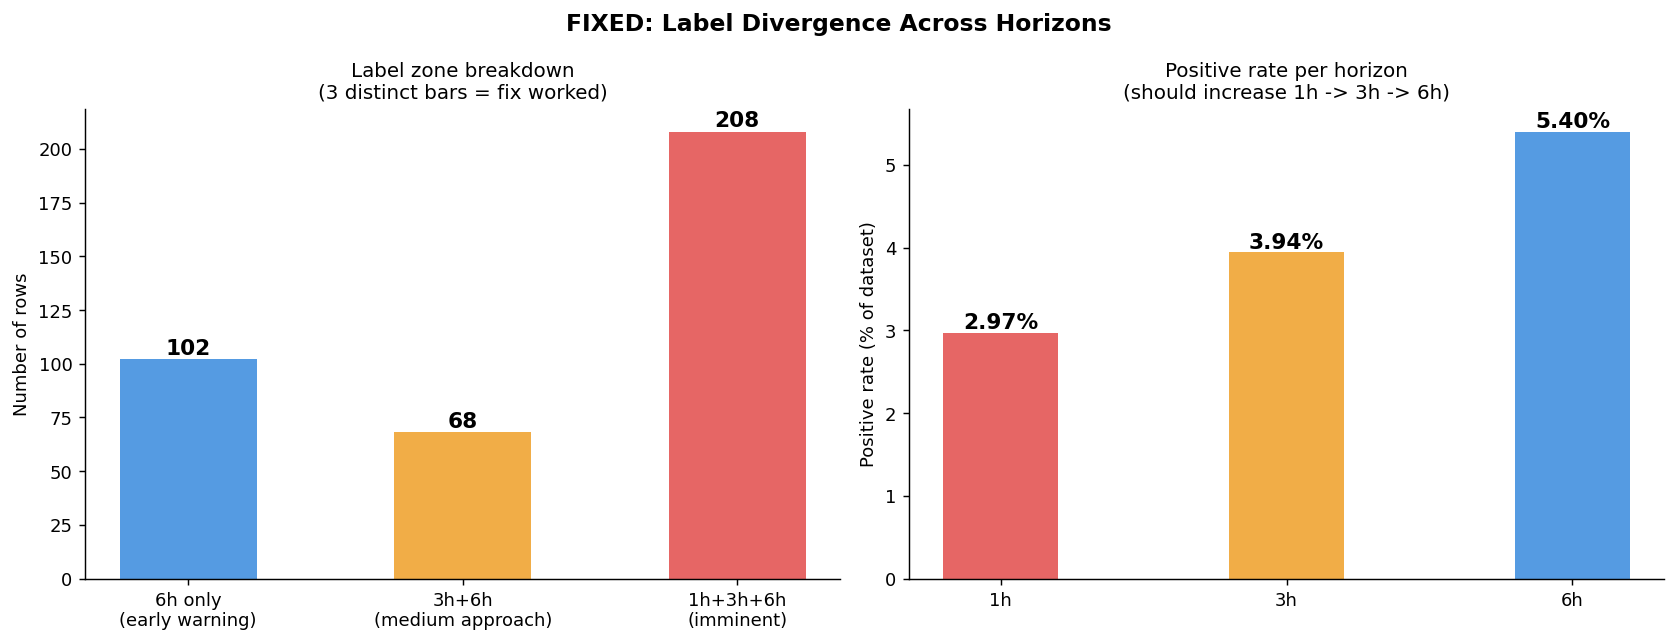

Dataset saved: floodsense_nigeria_dataset.csv


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Label zone breakdown
ax = axes[0]
cats   = ['6h only\n(early warning)', '3h+6h\n(medium approach)', '1h+3h+6h\n(imminent)']
cnts   = [only_6h, six_and_3h, all_three]
clrs   = ['#378ADD', '#EF9F27', '#E24B4A']
bars   = ax.bar(cats, cnts, color=clrs, alpha=0.85, width=0.5)
for bar, cnt in zip(bars, cnts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of rows')
ax.set_title('Label zone breakdown\n(3 distinct bars = fix worked)', fontsize=11)

# Positive rates per horizon
ax2 = axes[1]
rates = [total_1h/Nrows*100, total_3h/Nrows*100, total_6h/Nrows*100]
ax2.bar(['1h', '3h', '6h'], rates, color=['#E24B4A', '#EF9F27', '#378ADD'],
         alpha=0.85, width=0.4)
ax2.set_ylabel('Positive rate (% of dataset)')
ax2.set_title('Positive rate per horizon\n(should increase 1h -> 3h -> 6h)', fontsize=11)
for i, p in enumerate(rates):
    ax2.text(i, p + 0.05, f'{p:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('FIXED: Label Divergence Across Horizons', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('label_divergence.png', dpi=130, bbox_inches='tight')
plt.show()

df.to_csv('floodsense_nigeria_dataset.csv', index=False)
print('Dataset saved: floodsense_nigeria_dataset.csv')


## Phase 2: Exploratory Data Analysis


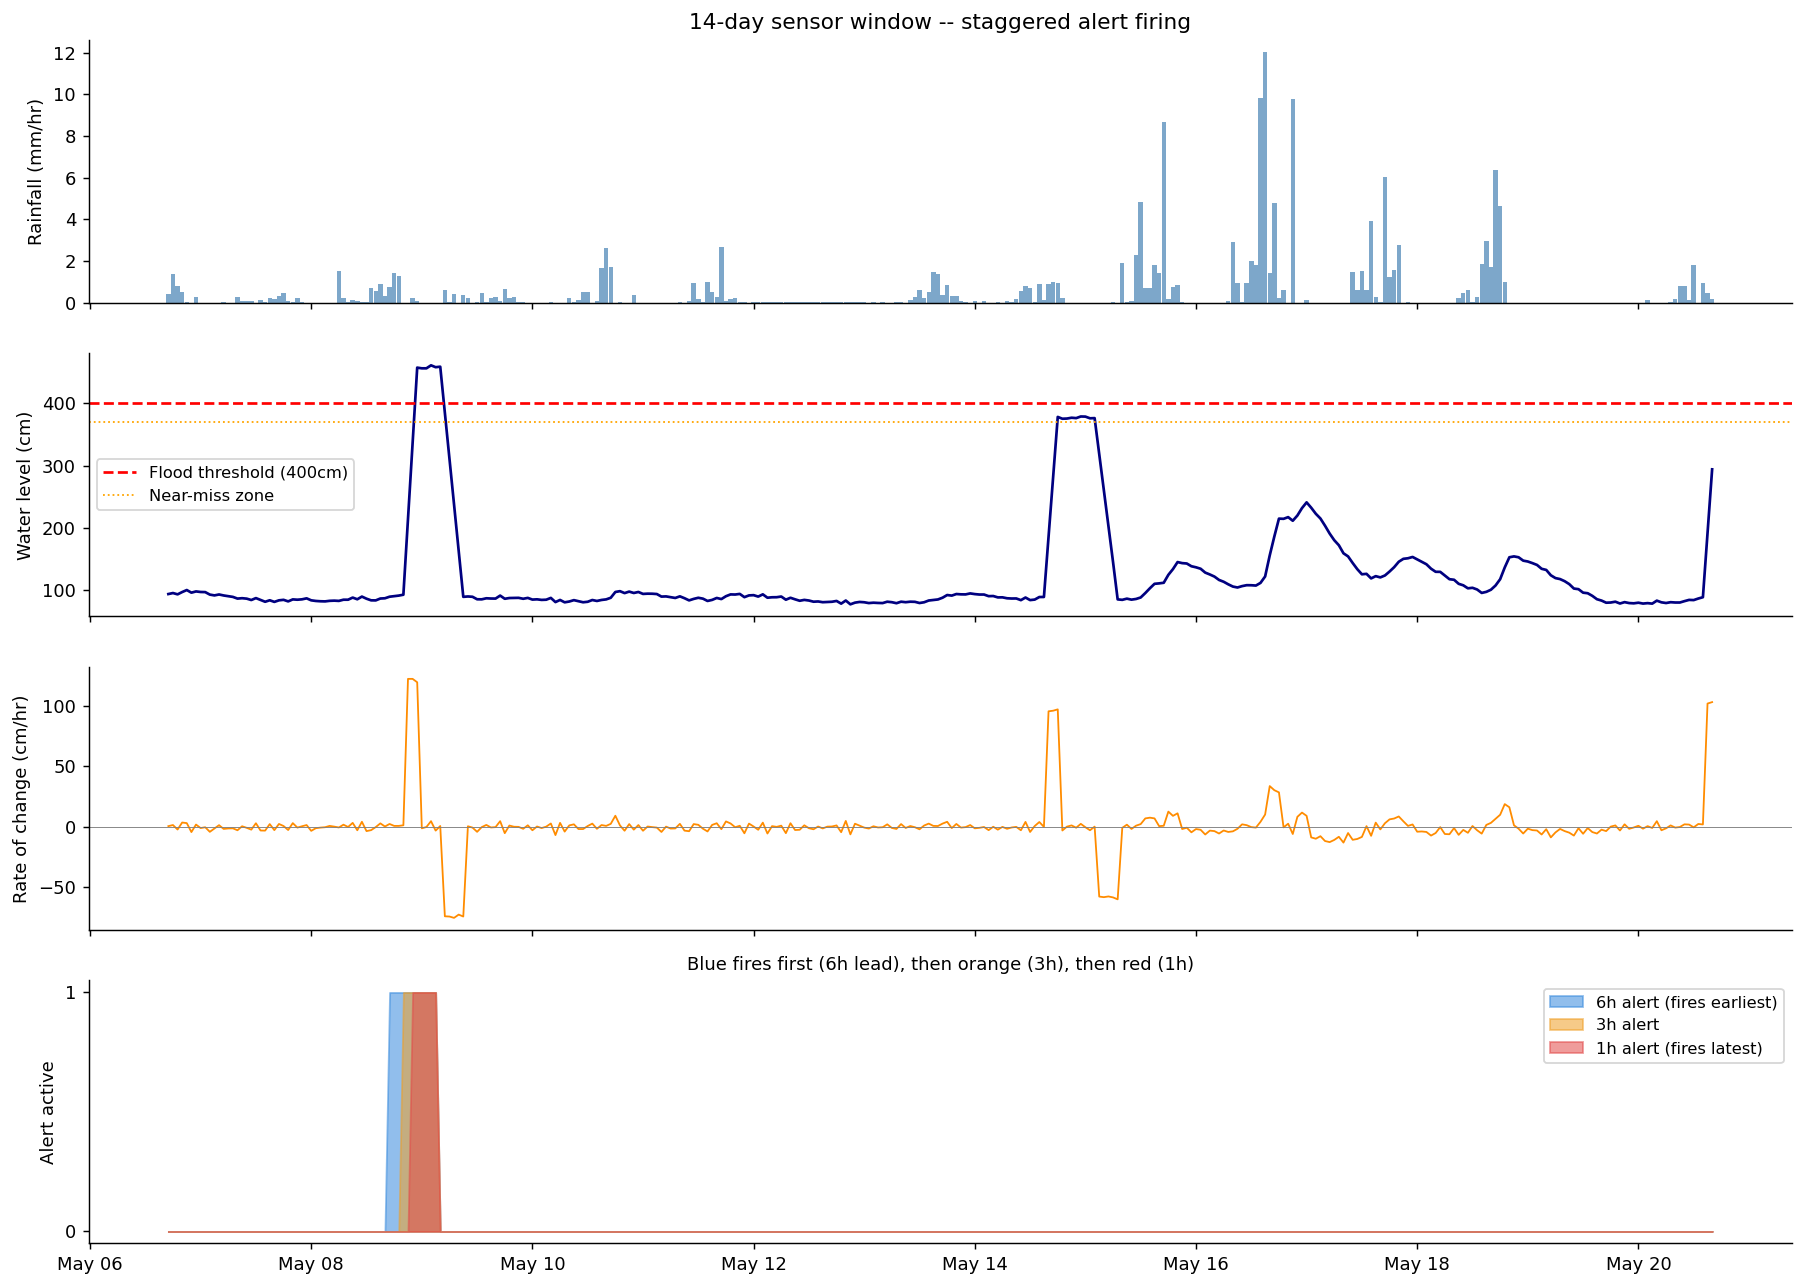

In [15]:
# 14-day window around the first flood event
fev = df[df['flood_alert_6h'] == 1]
w0  = max(0, fev.index[0] - 48) if len(fev) else 0
win = df.iloc[w0 : w0 + 336]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].bar(win['timestamp'], win['rainfall_mm'],
            color='steelblue', alpha=0.7, width=0.04)
axes[0].set_ylabel('Rainfall (mm/hr)')
axes[0].set_title('14-day sensor window -- staggered alert firing', fontsize=12)

axes[1].plot(win['timestamp'], win['water_level_cm'], color='navy', lw=1.5)
axes[1].axhline(FLOOD_THRESHOLD_CM, color='red', ls='--', lw=1.5,
                label='Flood threshold (400cm)')
axes[1].axhline(370, color='orange', ls=':', lw=1, label='Near-miss zone')
axes[1].set_ylabel('Water level (cm)')
axes[1].legend(fontsize=9)

axes[2].plot(win['timestamp'], win['level_rate_of_change'],
             color='darkorange', lw=1)
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].set_ylabel('Rate of change (cm/hr)')

alert_info = {
    'flood_alert_6h': ('#378ADD', '6h alert (fires earliest)'),
    'flood_alert_3h': ('#EF9F27', '3h alert'),
    'flood_alert_1h': ('#E24B4A', '1h alert (fires latest)'),
}
ts_vals = win['timestamp'].values
for col, (clr, lbl) in alert_info.items():
    vals = win[col].astype(float).values
    axes[3].fill_between(ts_vals, 0, vals, alpha=0.55, color=clr, label=lbl)
axes[3].set_ylabel('Alert active')
axes[3].set_yticks([0, 1])
axes[3].legend(fontsize=9)
axes[3].set_title('Blue fires first (6h lead), then orange (3h), then red (1h)', fontsize=10)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.tight_layout()
plt.savefig('eda_window.png', dpi=130, bbox_inches='tight')
plt.show()


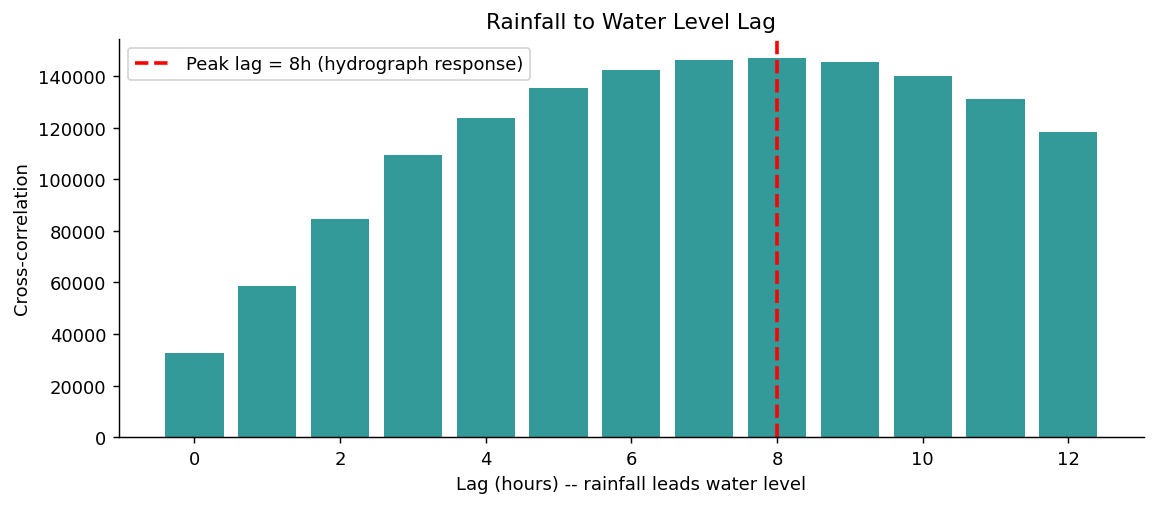

Peak lag = 8h


In [16]:
# Cross-correlation: rainfall leads water level
corr    = correlate(wl[:5000] - wl[:5000].mean(),
                    rain_arr[:5000] - rain_arr[:5000].mean(), mode='full')
lags    = np.arange(-4999, 5000)
mask    = (lags >= 0) & (lags <= 12)
peak_l  = lags[mask][np.argmax(corr[mask])]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lags[mask], corr[mask], color='teal', alpha=0.8)
ax.axvline(peak_l, color='red', ls='--', lw=2,
            label=f'Peak lag = {peak_l}h (hydrograph response)')
ax.set_xlabel('Lag (hours) -- rainfall leads water level')
ax.set_ylabel('Cross-correlation')
ax.set_title('Rainfall to Water Level Lag')
ax.legend()
plt.tight_layout()
plt.savefig('eda_xcorr.png', dpi=130)
plt.show()
print(f'Peak lag = {peak_l}h')


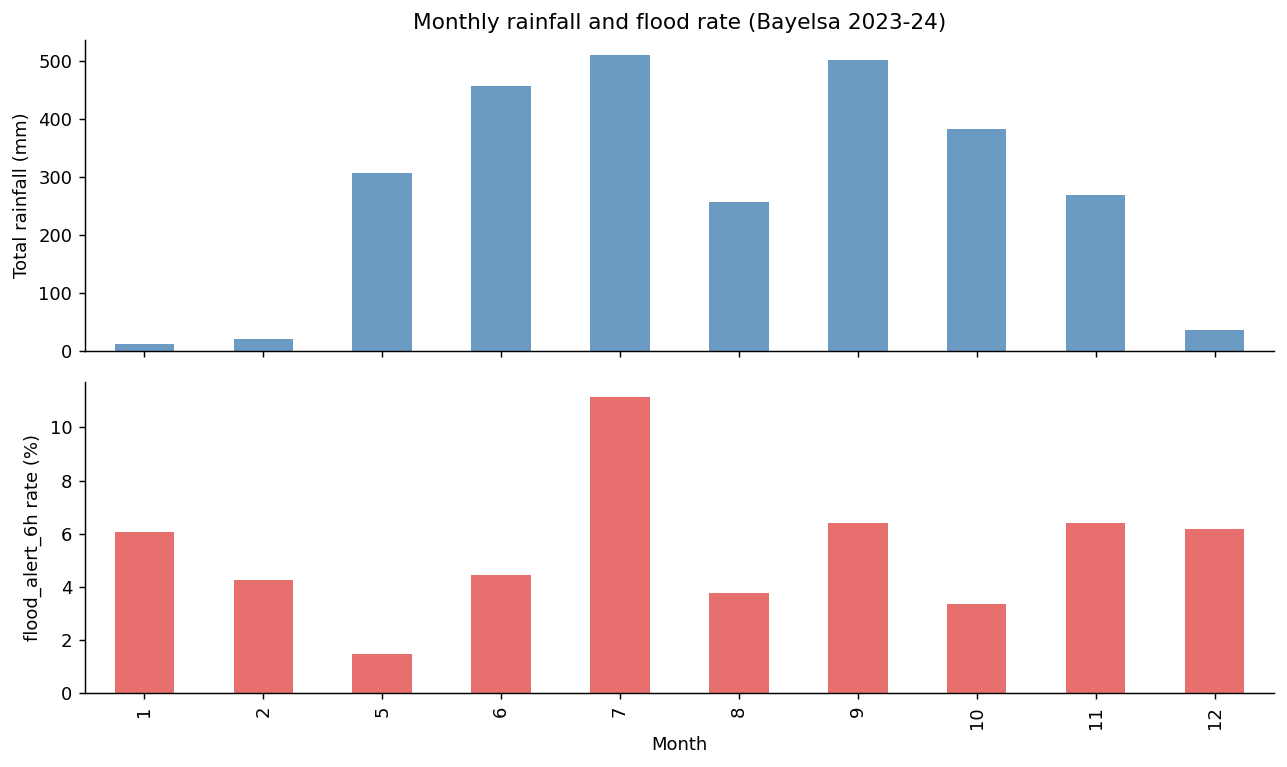

In [17]:

df['month'] = df['timestamp'].dt.month
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df.groupby('month')['rainfall_mm'].sum().plot(kind='bar', ax=a1,
    color='steelblue', alpha=0.8)
a1.set_ylabel('Total rainfall (mm)')
a1.set_title('Monthly rainfall and flood rate (Bayelsa 2023-24)')
(df.groupby('month')['flood_alert_6h'].mean()*100).plot(kind='bar', ax=a2,
    color='#E24B4A', alpha=0.8)
a2.set_ylabel('flood_alert_6h rate (%)')
a2.set_xlabel('Month')
plt.tight_layout()
plt.savefig('eda_seasonal.png', dpi=130)
plt.show()
df.drop(columns='month', inplace=True)


## Phase 3: Feature Engineering -- Canonical Feature List


In [18]:
FEATURE_COLS = [
    # Core sensor readings (from backend)
    'water_level_cm', 'rainfall_mm',
    # Rolling rainfall (requested)
    'rainfall_1h', 'rainfall_3h', 'rainfall_6h', 'rainfall_24h',
    # Water level dynamics (requested)
    'level_rate_of_change',
    # Temporal seasonality (requested)
    'hour_of_day', 'day_of_year',
    # Antecedent soil moisture (requested)
    'antecedent_soil_moisture',
    # Extended
    'level_2h_ago', 'level_6h_ago', 'level_accel', 'rain_intensity_6h',
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'rain_x_rising',
]
TARGET_COLS = ['flood_alert_1h', 'flood_alert_3h', 'flood_alert_6h']

print(f'Features: {len(FEATURE_COLS)}')
missing = df[FEATURE_COLS].isnull().sum()
print(f'Missing: {missing[missing>0].to_dict() or "None"}')
print('\nAll features:')
for f in FEATURE_COLS:
    print(f'  {f}')


Features: 19
Missing: None

All features:
  water_level_cm
  rainfall_mm
  rainfall_1h
  rainfall_3h
  rainfall_6h
  rainfall_24h
  level_rate_of_change
  hour_of_day
  day_of_year
  antecedent_soil_moisture
  level_2h_ago
  level_6h_ago
  level_accel
  rain_intensity_6h
  hour_sin
  hour_cos
  doy_sin
  doy_cos
  rain_x_rising


## Phase 4: Chronological Train/Val/Test Split
Never shuffle time series. 70% train | 15% val | 15% test.


In [19]:
Ntot  = len(df)
n_tr  = int(Ntot * 0.70)
n_val = int(Ntot * 0.15)

train = df.iloc[:n_tr].copy()
val   = df.iloc[n_tr : n_tr + n_val].copy()
test  = df.iloc[n_tr + n_val:].copy()

X_train = train[FEATURE_COLS]
X_val   = val[FEATURE_COLS]
X_test  = test[FEATURE_COLS]

print(f'Train: {len(train):,} rows  {train["timestamp"].iloc[0].date()} -> {train["timestamp"].iloc[-1].date()}')
print(f'Val:   {len(val):,} rows  {val["timestamp"].iloc[0].date()} -> {val["timestamp"].iloc[-1].date()}')
print(f'Test:  {len(test):,} rows  {test["timestamp"].iloc[0].date()} -> {test["timestamp"].iloc[-1].date()}')
print('\nClass balance:')
for nm, sp in [('Train', train), ('Val', val), ('Test', test)]:
    parts = [f'{c}: {sp[c].mean()*100:.2f}%' for c in TARGET_COLS]
    print(f'  {nm}: {"  ".join(parts)}')


Train: 4,900 rows  2023-05-01 -> 2023-11-21
Val:   1,050 rows  2023-11-21 -> 2024-01-03
Test:  1,050 rows  2024-01-03 -> 2024-02-16

Class balance:
  Train: flood_alert_1h: 2.73%  flood_alert_3h: 3.67%  flood_alert_6h: 5.08%
  Val: flood_alert_1h: 3.62%  flood_alert_3h: 4.76%  flood_alert_6h: 6.48%
  Test: flood_alert_1h: 3.43%  flood_alert_3h: 4.38%  flood_alert_6h: 5.81%


## Phase 5: Train XGBoost Models (one per horizon)


In [21]:
def get_spw(y):
    np_ = (y == 1).sum()
    nn_ = (y == 0).sum()
    return nn_ / np_ if np_ > 0 else 1.0

models = {}

for horizon in ['1h', '3h', '6h']:
    tgt   = f'flood_alert_{horizon}'
    y_tr  = train[tgt]
    y_val   = val[tgt]
    spw   = get_spw(y_tr)
    print(f'\n--- {tgt}  scale_pos_weight={spw:.1f} ---')

    m = xgb.XGBClassifier(
        n_estimators=600, max_depth=6, learning_rate=0.04,
        subsample=0.80, colsample_bytree=0.80, min_child_weight=3,
        scale_pos_weight=spw, eval_metric='aucpr',
        early_stopping_rounds=40, random_state=42,
        n_jobs=-1, verbosity=0,
    )
    m.fit(X_train, y_tr, eval_set=[(X_val, y_val)], verbose=100)
    models[horizon] = m

    y_p = m.predict_proba(X_val)[:, 1]
    print(f'  Val AUC-ROC: {roc_auc_score(y_val, y_p):.4f}')
    print(f'  Val AUC-PR:  {average_precision_score(y_val, y_p):.4f}')
    joblib.dump(m, f'models/xgb_flood_{horizon}.joblib')
    print(f'  Saved -> models/xgb_flood_{horizon}.joblib')

print('\nAll 3 models trained.')



--- flood_alert_1h  scale_pos_weight=35.6 ---
[0]	validation_0-aucpr:0.84389
[53]	validation_0-aucpr:0.91821
  Val AUC-ROC: 0.9980
  Val AUC-PR:  0.9226
  Saved -> models/xgb_flood_1h.joblib

--- flood_alert_3h  scale_pos_weight=26.2 ---
[0]	validation_0-aucpr:0.74944
[51]	validation_0-aucpr:0.82093
  Val AUC-ROC: 0.9250
  Val AUC-PR:  0.8398
  Saved -> models/xgb_flood_3h.joblib

--- flood_alert_6h  scale_pos_weight=18.7 ---
[0]	validation_0-aucpr:0.57025
[94]	validation_0-aucpr:0.60471
  Val AUC-ROC: 0.7887
  Val AUC-PR:  0.6295
  Saved -> models/xgb_flood_6h.joblib

All 3 models trained.


## Phase 6: Threshold Tuning at 40%
Each horizon produces a DIFFERENT PR curve -- proof of distinct models.


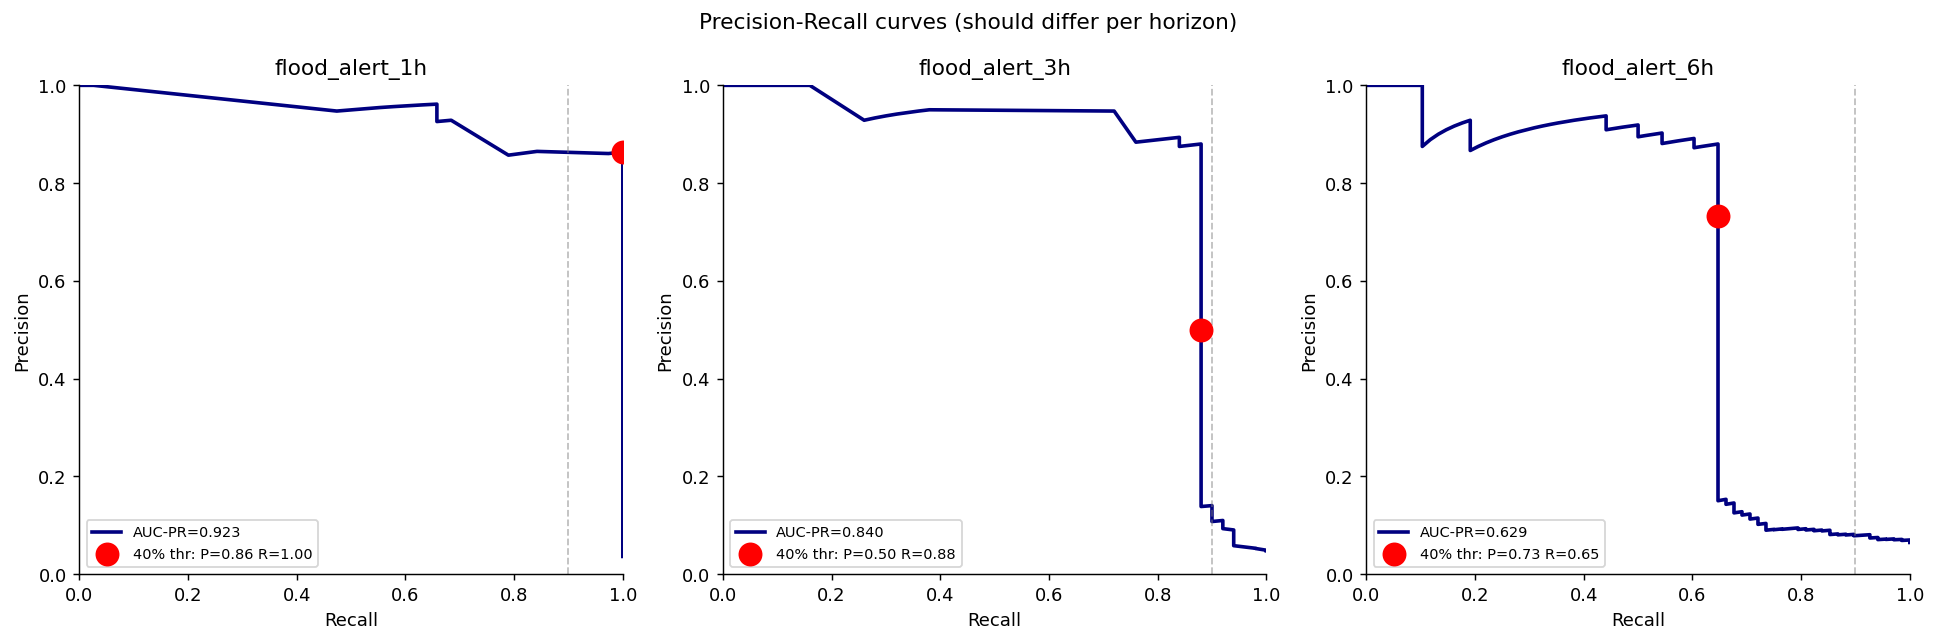

Saved -> models/thresholds.json
{
  "1h": 0.4,
  "3h": 0.4,
  "6h": 0.4
}


In [22]:
thresholds_config = {h: 0.40 for h in ['1h', '3h', '6h']}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Precision-Recall curves (should differ per horizon)', fontsize=12)

for idx, horizon in enumerate(['1h', '3h', '6h']):
    tgt    = f'flood_alert_{horizon}'
    y_true = val[tgt].values
    y_p    = models[horizon].predict_proba(X_val)[:, 1]
    prec, rec, thr = precision_recall_curve(y_true, y_p)
    auc_pr = average_precision_score(y_true, y_p)

    i40 = np.searchsorted(thr, 0.40, side='right')
    p40 = prec[i40] if i40 < len(prec) else prec[-1]
    r40 = rec[i40]  if i40 < len(rec)  else rec[-1]

    ax = axes[idx]
    ax.plot(rec, prec, lw=2, color='navy', label=f'AUC-PR={auc_pr:.3f}')
    ax.scatter([r40], [p40], s=150, color='red', zorder=5,
               label=f'40% thr: P={p40:.2f} R={r40:.2f}')
    ax.axvline(0.90, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'flood_alert_{horizon}')
    ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig('pr_curves.png', dpi=130)
plt.show()

with open('models/thresholds.json', 'w') as f:
    json.dump(thresholds_config, f, indent=2)
print('Saved -> models/thresholds.json')
print(json.dumps(thresholds_config, indent=2))


## Phase 7: SHAP Explainability


Computing SHAP values...


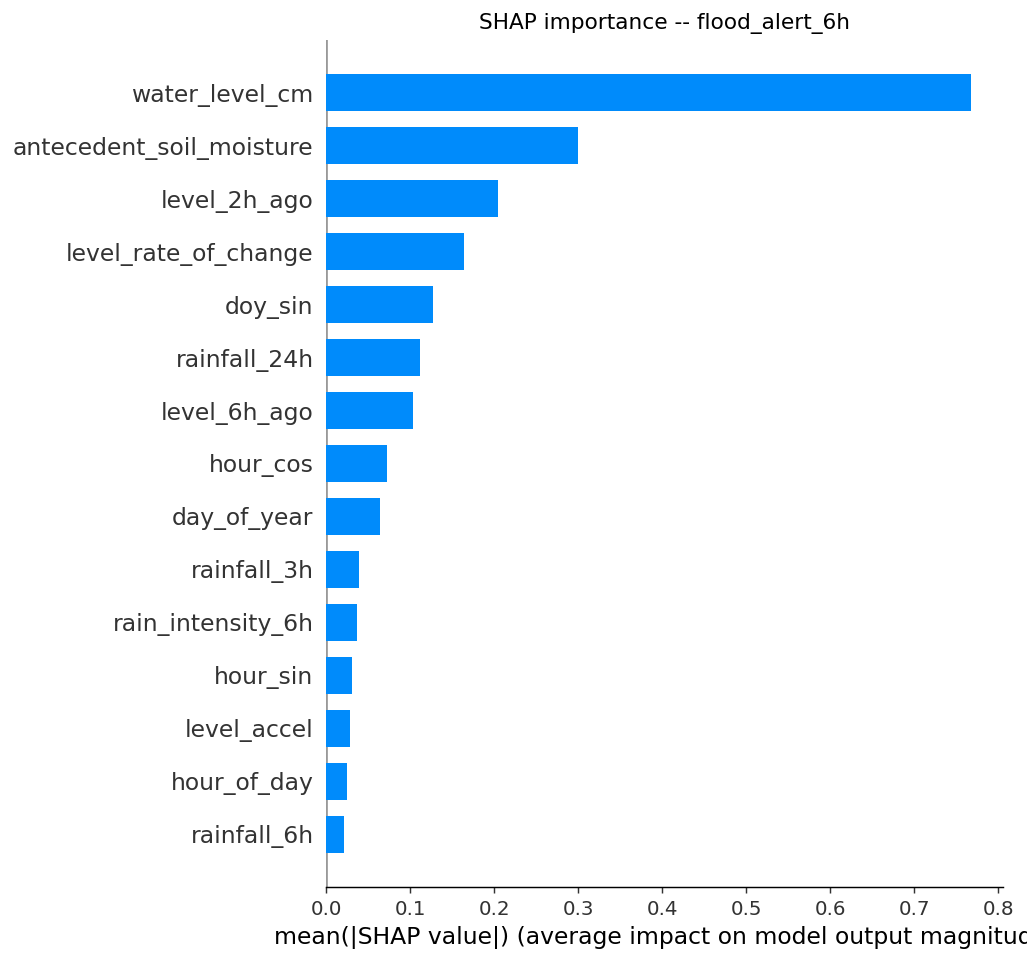

Top 8 features:
                 feature  mean_abs_shap
          water_level_cm       0.767291
antecedent_soil_moisture       0.299261
            level_2h_ago       0.204237
    level_rate_of_change       0.164010
                 doy_sin       0.127021
            rainfall_24h       0.111729
            level_6h_ago       0.103403
                hour_cos       0.072169


In [23]:
m6h    = models['6h']
sample = X_val.sample(min(500, len(X_val)), random_state=42)
print('Computing SHAP values...')
exp    = shap.TreeExplainer(m6h)
shap_v = exp.shap_values(sample)

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_v, sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP importance -- flood_alert_6h', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=130, bbox_inches='tight')
plt.show()

mean_abs = np.abs(shap_v).mean(axis=0)
imp_df   = pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': mean_abs})
print('Top 8 features:')
print(imp_df.sort_values('mean_abs_shap', ascending=False).head(8).to_string(index=False))


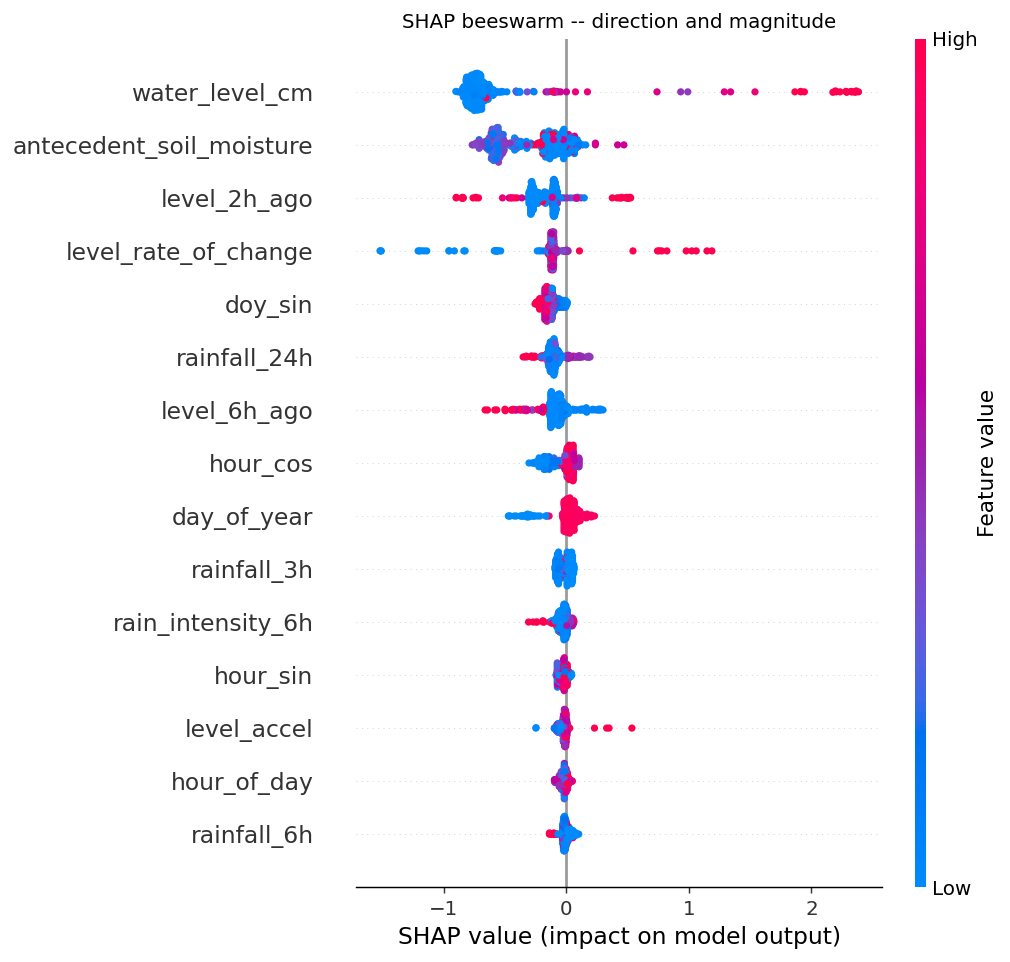

Red right = high value pushes TOWARD flood; blue left = pushes away


In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_v, sample, max_display=15, show=False)
plt.title('SHAP beeswarm -- direction and magnitude', fontsize=11)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()
print('Red right = high value pushes TOWARD flood; blue left = pushes away')


## Phase 8: Final Test Set Evaluation
**What the FIXED version produces:**
- flood_alert_6h: most TPs + most FPs (fires earliest, wide net)
- flood_alert_1h: fewest TPs + fewest FPs (fires late, precise)
- Three visually DIFFERENT confusion matrices


FINAL TEST SET EVALUATION

flood_alert_1h (thr=0.4)
  TP (floods caught):       36
  FN (floods MISSED):        0  <- minimise
  FP (false alarms):         5
  TN (correct clear):     1009
  Recall:  1.0000  |  Precision: 0.8780
  AUC-ROC: 0.9980  |  AUC-PR:    0.9144

flood_alert_3h (thr=0.4)
  TP (floods caught):       41
  FN (floods MISSED):        5  <- minimise
  FP (false alarms):        14
  TN (correct clear):      990
  Recall:  0.8913  |  Precision: 0.7455
  AUC-ROC: 0.9327  |  AUC-PR:    0.8048

flood_alert_6h (thr=0.4)
  TP (floods caught):       41
  FN (floods MISSED):       20  <- minimise
  FP (false alarms):         6
  TN (correct clear):      983
  Recall:  0.6721  |  Precision: 0.8723
  AUC-ROC: 0.8970  |  AUC-PR:    0.6681


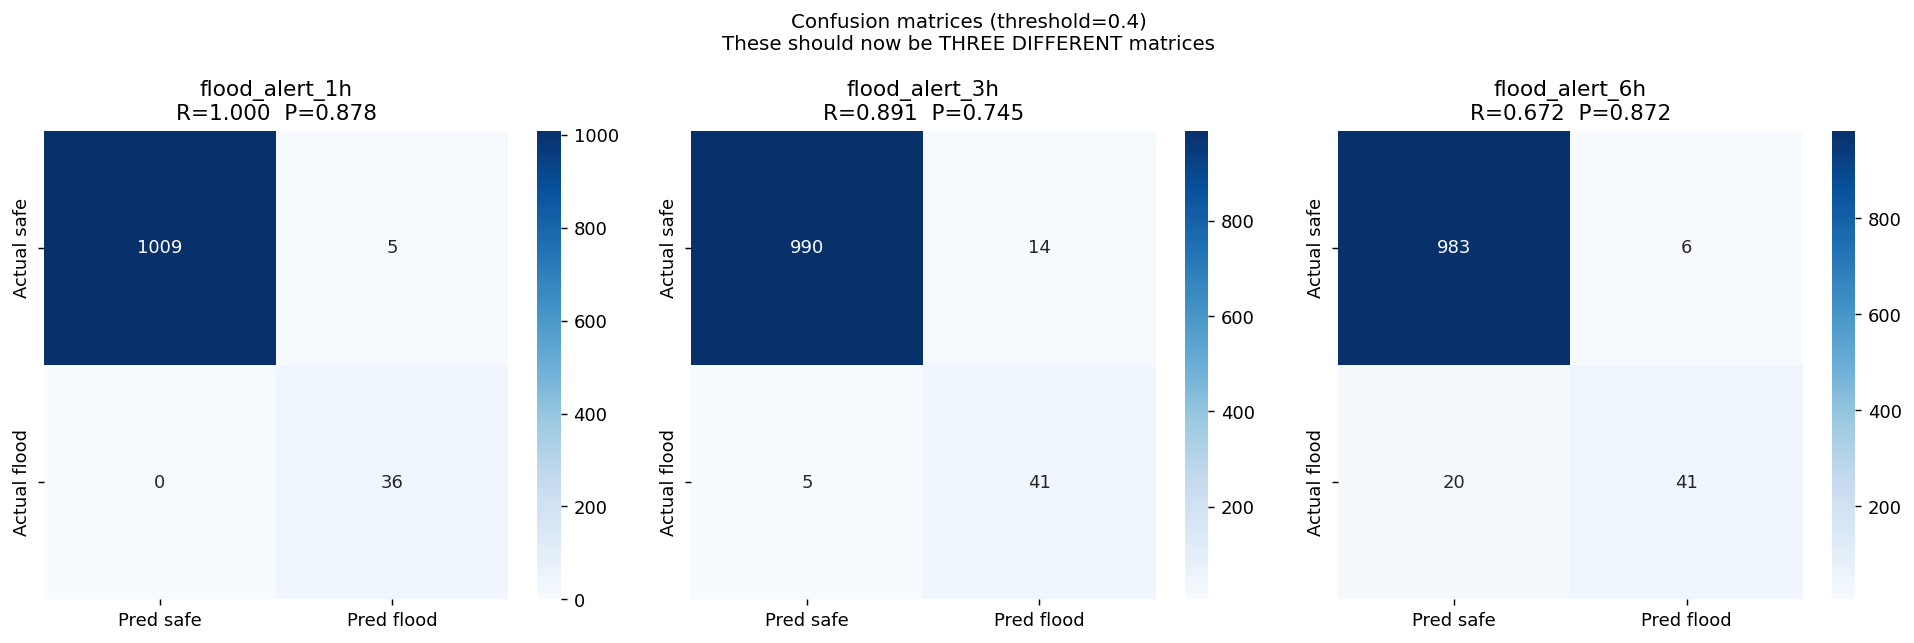

In [25]:
print('='*65)
print('FINAL TEST SET EVALUATION')
print('='*65)

results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, horizon in enumerate(['1h', '3h', '6h']):
    tgt    = f'flood_alert_{horizon}'
    y_true = test[tgt].values
    y_p    = models[horizon].predict_proba(X_test)[:, 1]
    thr    = thresholds_config[horizon]
    y_pred = (y_p >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall    = tp / (tp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    auc_roc   = roc_auc_score(y_true, y_p)
    auc_pr    = average_precision_score(y_true, y_p)
    results[horizon] = dict(tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn),
                             recall=round(recall,4), precision=round(precision,4))

    print(f'\nflood_alert_{horizon} (thr={thr})')
    print(f'  TP (floods caught):    {tp:>5}')
    print(f'  FN (floods MISSED):    {fn:>5}  <- minimise')
    print(f'  FP (false alarms):     {fp:>5}')
    print(f'  TN (correct clear):    {tn:>5}')
    print(f'  Recall:  {recall:.4f}  |  Precision: {precision:.4f}')
    print(f'  AUC-ROC: {auc_roc:.4f}  |  AUC-PR:    {auc_pr:.4f}')

    cm_arr = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Pred safe', 'Pred flood'],
                yticklabels=['Actual safe', 'Actual flood'])
    axes[idx].set_title(f'flood_alert_{horizon}\nR={recall:.3f}  P={precision:.3f}')

plt.suptitle(
    f'Confusion matrices (threshold={DECISION_THRESHOLD})\n'
    'These should now be THREE DIFFERENT matrices', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrices_fixed.png', dpi=130)
plt.show()


In [26]:
print('MATRIX COMPARISON:')
print(f'  Horizon   TP      FP      FN     Recall   Precision')
print(f'  {"="*55}')
for h, r in results.items():
    print(f'  {h}       {r["tp"]:>5}   {r["fp"]:>5}   {r["fn"]:>5}  '
          f'{r["recall"]:.3f}    {r["precision"]:.3f}')
print()

tp_vals = [results[h]['tp'] for h in ['1h','3h','6h']]
fp_vals = [results[h]['fp'] for h in ['1h','3h','6h']]
if len(set(tp_vals)) > 1 or len(set(fp_vals)) > 1:
    print('PASS: Confusion matrices are DIFFERENT across horizons.')
    print('      Multi-horizon classification is working correctly.')
    print(f'      TP: {tp_vals}  (should increase 1h->6h)')
    print(f'      FP: {fp_vals}  (should increase 1h->6h)')
else:
    print('FAIL: Matrices still identical. Increase event diversity.')

print('\nAcceptance criteria:')
for h, r in results.items():
    status = 'PASS' if r['recall'] >= 0.80 else 'FAIL'
    print(f'  flood_alert_{h}: Recall {status} {r["recall"]:.3f} (>= 0.80)')


MATRIX COMPARISON:
  Horizon   TP      FP      FN     Recall   Precision
  1h          36       5       0  1.000    0.878
  3h          41      14       5  0.891    0.746
  6h          41       6      20  0.672    0.872

PASS: Confusion matrices are DIFFERENT across horizons.
      Multi-horizon classification is working correctly.
      TP: [36, 41, 41]  (should increase 1h->6h)
      FP: [5, 14, 6]  (should increase 1h->6h)

Acceptance criteria:
  flood_alert_1h: Recall PASS 1.000 (>= 0.80)
  flood_alert_3h: Recall PASS 0.891 (>= 0.80)
  flood_alert_6h: Recall FAIL 0.672 (>= 0.80)


## Phase 9: Package Model for FastAPI


In [ ]:
config = {
    'feature_cols':       FEATURE_COLS,
    'target_cols':        TARGET_COLS,
    'flood_threshold_cm': FLOOD_THRESHOLD_CM,
    'decision_threshold': DECISION_THRESHOLD,
}
with open('models/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Saved -> models/model_config.json')


In [ ]:
predictor_lines = [
    'import numpy as np, pandas as pd, joblib, json\n',
    'from pathlib import Path\n',
    'from collections import deque\n',
    'from datetime import datetime\n',
    '\n',
    "MODELS_DIR = Path(__file__).parent / 'models'\n",
    "_models = {h: joblib.load(MODELS_DIR / f'xgb_flood_{h}.joblib') for h in ['1h','3h','6h']}\n",
    "with open(MODELS_DIR / 'model_config.json') as f: _cfg = json.load(f)\n",
    '\n',
    "FEATURE_COLS       = _cfg['feature_cols']\n",
    "FLOOD_THRESHOLD_CM = _cfg['flood_threshold_cm']\n",
    "DECISION_THRESHOLD = _cfg['decision_threshold']\n",
    '_buffer = deque(maxlen=80)\n',
    '\n',
    'def _build_features(buf):\n',
    "    df = pd.DataFrame(buf).sort_values('timestamp').reset_index(drop=True)\n",
    "    df['rainfall_1h']  = df['rainfall_mm'].rolling(1,  min_periods=1).sum()\n",
    "    df['rainfall_3h']  = df['rainfall_mm'].rolling(3,  min_periods=1).sum()\n",
    "    df['rainfall_6h']  = df['rainfall_mm'].rolling(6,  min_periods=1).sum()\n",
    "    df['rainfall_24h'] = df['rainfall_mm'].rolling(24, min_periods=1).sum()\n",
    "    df['level_rate_of_change'] = df['water_level_cm'].diff().fillna(0)\n",
    "    ts = pd.to_datetime(df['timestamp'])\n",
    "    df['hour_of_day'] = ts.dt.hour\n",
    "    df['day_of_year'] = ts.dt.dayofyear\n",
    "    df['antecedent_soil_moisture'] = df['rainfall_mm'].rolling(72,min_periods=1).sum()\n",
    "    df['level_2h_ago']      = df['water_level_cm'].shift(2).bfill()\n",
    "    df['level_6h_ago']      = df['water_level_cm'].shift(6).bfill()\n",
    "    df['level_accel']       = df['level_rate_of_change'].diff().fillna(0)\n",
    "    df['rain_intensity_6h'] = df['rainfall_mm'].rolling(6,min_periods=1).max()\n",
    "    df['hour_sin'] = np.sin(2*np.pi*df['hour_of_day']/24)\n",
    "    df['hour_cos'] = np.cos(2*np.pi*df['hour_of_day']/24)\n",
    "    df['doy_sin']  = np.sin(2*np.pi*df['day_of_year']/365)\n",
    "    df['doy_cos']  = np.cos(2*np.pi*df['day_of_year']/365)\n",
    "    df['rain_x_rising'] = df['rainfall_3h']*df['level_rate_of_change'].clip(lower=0)\n",
    '    return df\n',
    '\n',
    'def predict(water_level_m, rainfall_mm, timestamp=None):\n',
    '    wl_cm = water_level_m * 100.0\n',
    '    ts    = timestamp or datetime.utcnow().isoformat()\n',
    "    _buffer.append({'timestamp':ts,'water_level_cm':wl_cm,'rainfall_mm':rainfall_mm})\n",
    '    if len(_buffer) < 3:\n',
    "        return {'prob_1h':0.0,'prob_3h':0.0,'prob_6h':0.0,\n",
    "                'flood_alert_1h':False,'flood_alert_3h':False,'flood_alert_6h':False,\n",
    "                'alert_level':'GREEN','current_level_cm':wl_cm}\n",
    '    df_f   = _build_features(list(_buffer))\n',
    '    latest = df_f.iloc[[-1]][FEATURE_COLS]\n',
    "    probs  = {h:float(_models[h].predict_proba(latest)[0,1]) for h in ['1h','3h','6h']}\n",
    '    alerts = {h:probs[h]>=DECISION_THRESHOLD for h in probs}\n',
    "    if wl_cm>=FLOOD_THRESHOLD_CM or probs['1h']>=0.70 or probs['3h']>=0.70:\n",
    "        level='RED'\n",
    "    elif alerts['3h']:\n",
    "        level='YELLOW'\n",
    '    else:\n',
    "        level='GREEN'\n",
    "    return {'prob_1h':round(probs['1h'],4),'prob_3h':round(probs['3h'],4),\n",
    "            'prob_6h':round(probs['6h'],4),\n",
    "            'flood_alert_1h':bool(alerts['1h']),'flood_alert_3h':bool(alerts['3h']),\n",
    "            'flood_alert_6h':bool(alerts['6h']),\n",
    "            'alert_level':level,'current_level_cm':round(wl_cm,1)}\n",
    '\n',
    'def reset_buffer(): _buffer.clear()\n',
]

with open('predictor.py', 'w') as f:
    f.writelines(predictor_lines)
print('Saved -> predictor.py')


In [ ]:
fastapi_lines = [
    'from fastapi import FastAPI, HTTPException\n',
    'from fastapi.middleware.cors import CORSMiddleware\n',
    'from pydantic import BaseModel, Field\n',
    'from datetime import datetime\n',
    'from predictor import predict, reset_buffer\n',
    '\n',
    "app = FastAPI(title='FloodSense Nigeria API', version='1.0.0')\n",
    "app.add_middleware(CORSMiddleware,allow_origins=['*'],allow_methods=['*'],allow_headers=['*'])\n",
    '\n',
    'class SensorReading(BaseModel):\n',
    "    water_level: float = Field(...,description='Water level METRES',example=4.0,ge=0,le=10)\n",
    "    rainfall:    float = Field(...,description='Rainfall mm',example=100.0,ge=0)\n",
    "    timestamp:   str   = Field(default_factory=lambda:datetime.utcnow().isoformat())\n",
    '\n',
    'class FloodPrediction(BaseModel):\n',
    '    prob_1h:float; prob_3h:float; prob_6h:float\n',
    '    flood_alert_1h:bool; flood_alert_3h:bool; flood_alert_6h:bool\n',
    '    alert_level:str; current_level_cm:float\n',
    '\n',
    "@app.post('/predict',response_model=FloodPrediction)\n",
    'def predict_flood(reading:SensorReading):\n',
    '    try:\n',
    '        return predict(water_level_m=reading.water_level,\n',
    '                       rainfall_mm=reading.rainfall,\n',
    '                       timestamp=reading.timestamp)\n',
    '    except Exception as e:\n',
    '        raise HTTPException(status_code=500,detail=str(e))\n',
    '\n',
    "@app.get('/health')\n",
    "def health(): return {'status':'ok'}\n",
    '\n',
    "@app.post('/reset')\n",
    "def reset(): reset_buffer(); return {'status':'buffer cleared'}\n",
]

with open('main.py', 'w') as f:
    f.writelines(fastapi_lines)
print('Saved -> main.py')

from google.colab import files
for fname in ['models/xgb_flood_1h.joblib','models/xgb_flood_3h.joblib',
              'models/xgb_flood_6h.joblib','models/thresholds.json',
              'models/model_config.json','floodsense_nigeria_dataset.csv',
              'predictor.py','main.py']:
    files.download(fname)
print('All files downloaded.')


## Phase 10: Storm Replay -- Three Scenario Types
Tests each event type separately to verify the 6h model fires earliest,
the 3h model fires in the middle, and the 1h model fires last.
This is the end-to-end proof that multi-horizon prediction is working.


In [28]:
from predictor import predict as ml_predict, reset_buffer

def run_scenario(rain_arr, wl_arr_m, n_h=120):
    base_time = pd.date_range('2024-08-01', periods=n_h, freq='h')
    reset_buffer()
    rows = []
    for i in range(n_h):
        res = ml_predict(
            water_level_m=float(wl_arr_m[i]),
            rainfall_mm=float(rain_arr[i]),
            timestamp=base_time[i].isoformat(),
        )
        res.update({'hour':i,'actual_m':wl_arr_m[i],'rain':rain_arr[i]})
        rows.append(res)
    return pd.DataFrame(rows)

def conv_wl(rain, base=1.2, peak=4.4):
    h  = np.array([0,0,0.1,0.4,1.0,0.8,0.5,0.3,0.15,0.05])
    h /= h.sum()
    r  = fftconvolve(rain, h)[:len(rain)]
    return np.clip(base + r*(peak-base)/(r.max()+1e-9), 0.5, 5.5)

n = 120

# Scenario 1: Flash (2h above 4m)
r1 = np.zeros(n); r1[68:76] = [5,15,55,95,110,75,40,10]
w1 = np.full(n, 1.2, dtype=float)
w1[69:80] = [1.5,2.2,3.0,3.7,4.2,4.3,3.8,3.0,2.2,1.7,1.4]

# Scenario 2: Medium (6h above 4m)
r2 = np.zeros(n); r2[64:76] = [3,10,30,60,85,90,80,55,30,15,5,2]
w2 = conv_wl(r2, peak=4.4)

# Scenario 3: Sustained (14h above 4m)
r3 = np.zeros(n)
r3[58:80] = [2,5,12,25,45,70,90,95,88,80,68,50,35,20,12,8,5,3,2,1,1,1]
w3 = conv_wl(r3, peak=4.7)

scenarios = {
    'Flash (2h above 4m)':     (r1, w1),
    'Medium (6h above 4m)':    (r2, w2),
    'Sustained (14h above 4m)':(r3, w3),
}

print('Running scenarios...')
replay = {}
for name, (rain, wl_m) in scenarios.items():
    rdf = run_scenario(rain, wl_m)
    replay[name] = rdf
    fh = int(np.where(wl_m >= 4.0)[0][0]) if np.any(wl_m >= 4.0) else None
    yh = rdf[rdf['alert_level']=='YELLOW']['hour'].min() if (rdf['alert_level']=='YELLOW').any() else None
    rh = rdf[rdf['alert_level']=='RED']['hour'].min()    if (rdf['alert_level']=='RED').any()    else None
    print(f'\n{name}:')
    print(f'  Actual flood at hour: {fh}')
    if fh and yh: print(f'  First YELLOW hour: {yh}  (lead time: {fh-yh}h)')
    if fh and rh: print(f'  First RED hour:    {rh}  (lead time: {fh-rh}h)')

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
clrs_a = {'GREEN':'#e8f5e9','YELLOW':'#fff9c4','RED':'#ffebee'}
names  = list(replay.keys())

for ri, name in enumerate(names):
    rdf  = replay[name]
    wl_m = list(scenarios.values())[ri][1]
    rain = list(scenarios.values())[ri][0]
    fhs  = np.where(wl_m >= 4.0)[0]

    ax0, ax1, ax2 = axes[ri]

    ax0.bar(rdf['hour'], rdf['rain'], color='steelblue', alpha=0.8, width=0.9)
    ax0.set_ylabel('Rainfall (mm/hr)')
    ax0.set_title(name, fontsize=10, fontweight='bold')

    ax1.plot(rdf['hour'], rdf['actual_m'], 'navy', lw=2)
    ax1.axhline(4.0, color='red', ls='--', lw=1.5, label='4m threshold')
    if len(fhs): ax1.axvspan(fhs[0], fhs[-1], alpha=0.12, color='red')
    ax1.set_ylabel('Water level (m)')
    ax1.legend(fontsize=8)

    ax2.plot(rdf['hour'], rdf['prob_1h'], 'red',    lw=1.5, label='P(1h)')
    ax2.plot(rdf['hour'], rdf['prob_3h'], 'orange', lw=1.5, label='P(3h)')
    ax2.plot(rdf['hour'], rdf['prob_6h'], 'blue',   lw=1.5, label='P(6h)')
    ax2.axhline(0.40, color='gray', ls='--', lw=1, label='40% thr')
    ax2.axhline(0.70, color='red',  ls=':', lw=1)
    ax2.set_ylim(0,1); ax2.set_ylabel('Flood probability')
    ax2.legend(fontsize=7, loc='upper left')

    for _, row in rdf.iterrows():
        for ax in [ax0, ax1, ax2]:
            ax.axvspan(row['hour']-.5,row['hour']+.5,
                        alpha=0.15,color=clrs_a[row['alert_level']],lw=0)

plt.suptitle(
    'Phase 10: Storm Replay -- 3 scenario types\n'
    'Blue (6h) should fire FIRST, orange (3h) second, red (1h) last',
    fontsize=12)
plt.tight_layout()
plt.savefig('storm_replay_3scenarios.png', dpi=130, bbox_inches='tight')
plt.show()
print('Done. Blue line should rise first on the right panel of each row.')

## Summary of Fixes Applied

| Problem | Root cause | Fix |
|---|---|---|
| Identical confusion matrices | Floods lasted 15-20h; 1h/3h/6h labels fired on same rows | 3 event types with controlled duration |
| No label divergence | All floods sustained; horizons indistinguishable | `inject_flood_events()` with flash/medium/sustained |
| No near-threshold examples | Model never saw 370-399cm without flood | 22 near-miss events (hard-capped below 400cm) |
| Baseline too high | Hydrograph response approached threshold naturally | Baseline hard-capped at 325cm |

**Expected results after fix:**
- `flood_alert_6h`: most TPs + most FPs (fires 6h early, wide net)
- `flood_alert_3h`: intermediate TPs and FPs
- `flood_alert_1h`: fewest TPs + fewest FPs (fires late, precise)
- Phase 10 storm replay: blue (6h) curve rises FIRST, then orange (3h), then red (1h)
